In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader, random_split

import matplotlib.pyplot as plt
import numpy as np


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!cp -r /content/drive/MyDrive/DeepLearningProject/data/train/task2train540p /content/

In [ ]:
# mean=[0.3606, 0.3610, 0.3389],
# std=[0.1820, 0.1793, 0.2000]

image preprocessing + data augmentation pipeline in PyTorch.

In [ ]:
IMAGE_SIZE = 128

train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])

val_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])


transforms.Compose() applies multiple transformations in order.

---
Randomly flips image left ↔ right.
✔️ Helps model generalize
✔️ Prevents overfitting

---
Randomly rotates image between :
transforms.RandomRotation(15)

---
transforms.ToTensor() : Converts image to PyTorch tensor

Pixel Values : 0–255  →  0–1

(Height, Width, Channel) → (Channel, Height, Width)

Channels represent different layers of information in an image.

Every dataset has a different brightness & color distribution.

Example:

Medical images → darker

Traffic signs → bright red/yellow

Night images → low brightness

Snow scenes → very bright

If your dataset average pixel value is 0.65,
but you normalize using 0.5,
you are not truly centering your data.

Think of channels as separate sheets stacked together to form one image.

Grayscale images have:
1 channel Each pixel has only one value (brightness).

RGB : 3 channels

---

After ToTensor(), pixel values are scaled to: 0 → 1

But neural networks train even better when data is:
Centered around 0,
Has a consistent spread (variance)

mean = [0.5, 0.5, 0.5]
std  = [0.5, 0.5, 0.5]
There are 3 values because:

Channel 1 → Red

Channel 2 → Green

Channel 3 → Blue

Each channel is normalized separately.

---
O.5 to make value between -1 and 1

input is centered around 0:

Gradients flow better

Training becomes more stable

Learning is faster

If data is all positive (0 to 1):

Neurons may activate unevenly

Slower convergence

In [ ]:
train_path = "/content/task2train540p"

full_dataset = datasets.ImageFolder(root=train_path)

print("Total Images:", len(full_dataset))
print("Classes:", full_dataset.classes)


Total Images: 1000
Classes: ['gap-in-median', 'left-hand-curve', 'right-hand-curve', 'side-road-left']


ImageFolder:

✔ Reads all subfolders
✔ Automatically assigns labels
✔ Loads images
✔ Applies transformations

---
1.   Finds class folders

2.   Sorts them alphabetically

3.   Assigns numeric labels



In [ ]:
num_classes = len(full_dataset.classes)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_indices, val_indices = random_split(range(len(full_dataset)),
                                          [train_size, val_size])

train_dataset = datasets.ImageFolder(root=train_path,
                                     transform=train_transforms)

val_dataset = datasets.ImageFolder(root=train_path,
                                   transform=val_transforms)

train_dataset = torch.utils.data.Subset(train_dataset, train_indices.indices)
val_dataset = torch.utils.data.Subset(val_dataset, val_indices.indices)

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))


Train size: 800
Validation size: 200


0.8 * total → 80% for training

---
What random_split() does:

Randomly shuffles the dataset

Splits into two parts

Returns two subsets

---

val_dataset.dataset.transform = val_transforms

**Why is this needed?**

When you created full_dataset, you used:

  transform=train_transforms

**So both training and validation initially had:**

Random flip
, Random rotation

But validation data should NOT have augmentation.

**Validation must be:**

Clean
, Deterministic
, Same every time

So you overwrite the transform for validation.

**If you apply random transforms during validation:**

❌ The same image changes every time
❌ Accuracy becomes inconsistent
❌ You are not measuring true performance
❌ Results are noisy and unreliable

In [ ]:
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset,
                          batch_size=BATCH_SIZE,
                          shuffle=True)

val_loader = DataLoader(val_dataset,
                        batch_size=BATCH_SIZE,
                        shuffle=False)


Instead of training on one image at a time,
the model processes 32 images at once.

So training happens in small groups called batches.

---
What DataLoader Does:

Parameter num_workers : Speeds up data loading

Loads data efficiently

Creates batches

Shuffles data (if specified)

Makes iteration easy

---
Without shuffling model becomes biased as it sees similar data in sequence.

---

For each epoch:

1. DataLoader:

* Divides dataset into chunks of 32

2. Model:

*  Processes one batch

3. Loss computed

4. Backpropagation updates weights

5. Repeat for next batch

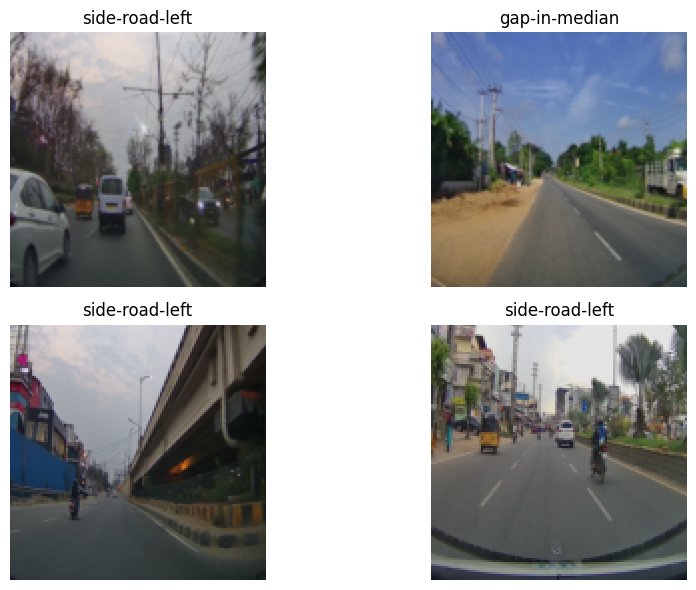

In [ ]:
data_iter = iter(train_loader)
images, labels = next(data_iter)

plt.figure(figsize=(10,6))

for i in range(4):
    img = images[i].permute(1,2,0)
    img = img * 0.5 + 0.5

    plt.subplot(2,2,i+1)
    plt.imshow(img)
    plt.title(full_dataset.classes[labels[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()


iter(train_loader) → creates an iterator

next(data_iter) → gets one batch

Now you have:

images → shape: (32, 3, 128, 128)
, labels → shape: (32,)

---

PyTorch stores images as:(C, H, W)

But matplotlib expects:(H, W, C)

So permute(1,2,0) changes: (3,128,128) → (128,128,3)

---
imshow() expects:

* 0 to 1

Unnormalize the Image : img = img * 0.5 + 0.5

Converts : [-1, 1] → [0, 1]

If you don’t do this:

❌ Image will look very dark or strange

---

plt.title(full_dataset.classes[labels[i]])
Explanation:

labels[i] → numeric label (like 0,1,2)

full_dataset.classes → list of class names
